In [72]:
import pandas as pd
import json
from globals import BASE_DIR, available_datasets, top_k_eval, valid_popularity, recommendation_dirpart
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import math
from postprocess_baseline_top_k import dataset_metadata
from evaluation_metrics import ndcg, calculate_arp_poplift, evaluation_user_group_means, jensen_shannon, behavioral_ild_per_user, geographic_ild_per_user, distance_traveled_per_user
from mmr_reranker import build_item_similarity
from geo_reranker import load_coordinates
import pingouin as pg


dataset = "foursquaretky" # perform for each dataset individually

len(available_datasets) # make sure the available datasets are correct since this affects the Bonferroni correction of the t-tests

2

In [73]:
print(top_k_eval)

10


In [74]:
def process_top_k_json(input_file, output_file, k=10):
    """
    Process top-k recommendations from a JSON file, keeping only the item IDs for each user.
    """
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    try:
        with open(input_file, "r") as infile:
            data = json.load(infile)

        top_k_result = {}
        for user_id, recommendations in data.items():
            if recommendations and isinstance(recommendations[0], dict):
                item_ids = recommendations[0]["item_id"][:k]
                top_k_result[user_id] = item_ids

        with open(output_file, "w") as outfile:
            json.dump(top_k_result, outfile, indent=4)
        print(f"Processed file saved to: {output_file}")
    
    except Exception as e:
        print(f"Error processing {input_file}: {e}")

In [75]:
def create_model_directories(dataset, data, base_dir, recommendation_dirpart):
    """
    Create output directories
    """
    model_directories = {}
    methods = ["baseline", "cp_min_js", "mmr", "geo", "borda", "schulze"]

    def recommender_dir_combiner(dataset, modelpart, method):
        return os.path.join(base_dir, f"{dataset}_dataset", recommendation_dirpart, modelpart, method, "top_k_recommendations.json")

    for result in data:
        model_name = result["model"]
        model_directories[model_name] = {}
        
        for method in methods:
            model_directories[model_name][method] = recommender_dir_combiner(dataset, result["directory"], method)
    
    return model_directories

def open_ground_truth_user_group(dataset, valid_popularity=valid_popularity):
    """Perform data splitting and user group creation."""

    train_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.train.inter"), sep="\t")
    test_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.test.inter"), sep="\t")
    valid_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.valid.inter"), sep="\t")

    print("Train data, test data and valid data shapes:")
    print(train_data.shape, test_data.shape, valid_data.shape)
    train_data = pd.concat([train_data, valid_data])
    user_group_dir = os.path.join(BASE_DIR, f"{dataset}_dataset", f"{dataset}_user_id_popularity.json")
    with open(user_group_dir) as f:
        user_groups = json.load(f)

    user_groups["HighPop"] = user_groups.pop("high")
    user_groups["LowPop"] = user_groups.pop("low")
    user_groups["MedPop"] = user_groups.pop("medium")



    checkin_df = train_data.copy()
    
    # Calculate item popularity
    value_counts = checkin_df["item_id:token"].value_counts().reset_index()
    value_counts.columns = ["item_id:token", "count"]
    value_counts[valid_popularity] = value_counts["count"] / len(value_counts)
    checkin_df = checkin_df.merge(
        value_counts[["item_id:token", valid_popularity]],
        on="item_id:token",
        how="left",
    )
    checkin_df.sort_values(by=valid_popularity, ascending=False, inplace=True)
    item_popularity = checkin_df.drop_duplicates(subset="item_id:token", keep="first")[
        ["item_id:token", valid_popularity]
    ]

    h_group = item_popularity.head(int(len(item_popularity) * 0.2))
    h_group["item_pop_group"] = "h"
    t_group = item_popularity.tail(int(len(item_popularity) * 0.2))
    t_group["item_pop_group"] = "t"
    m_group = item_popularity[
        ~item_popularity["item_id:token"].isin(h_group["item_id:token"]) &
        ~item_popularity["item_id:token"].isin(t_group["item_id:token"])
    ]
    m_group["item_pop_group"] = "m"

    item_popularity = pd.concat([h_group, m_group, t_group])
    item_popularity.sort_values(by=valid_popularity, inplace=True, ascending=False)

    upts = checkin_df.groupby("user_id:token")[valid_popularity].mean().reset_index()
    upts.columns = ["user_id:token", "upts"]
    return train_data, test_data, user_groups, item_popularity, upts


In [76]:
data = dataset_metadata(dataset, recommendation_dirpart)

In [77]:
model_dirs = create_model_directories(dataset, data, BASE_DIR, recommendation_dirpart)

In [78]:
def unstack_recommendations(df):
    """Unstack the recommendations for each user into separate rows."""
    unstacked_df = df.explode(["item_id:token"]).reset_index(drop=True)
    return unstacked_df

In [ ]:
def top_k_to_df(recommender_dir, top_k_eval=150):
    """ Fixed version that handles nested lists """
    with open(recommender_dir) as f:
        data = json.load(f)
    
    base_recommendations = []
    
    for user, items in data.items():
        # FIX: Check if items is nested [[...]]
        if isinstance(items, list) and len(items) > 0 and isinstance(items[0], list):
            # Flatten: items = [[...]] -> items = [...]
            items = items[0]
        
        # Now iterate through individual items
        for item in items:
            base_recommendations.append({
                "user_id:token": user,
                "item_id:token": item
            })
    
    base_df = pd.DataFrame(base_recommendations)
    base_df = unstack_recommendations(base_df)
    df = base_df.groupby("user_id:token").head(top_k_eval)
    
    return df

In [80]:
train_data, test_data, user_groups, item_popularity, upts = open_ground_truth_user_group(dataset)
user_groups["All"] = user_groups["HighPop"] + user_groups["MedPop"] + user_groups["LowPop"]

Train data, test data and valid data shapes:
(44414, 3) (14484, 3) (10503, 3)


In [81]:
test_data

,user_id:token,item_id:token,checkin_count:float
0,0_x,1516_x,2
1,0_x,2218_x,1
2,0_x,398_x,1
3,0_x,616_x,1
4,0_x,2627_x,3
...,...,...,...
14479,9_x,1171_x,1
14480,9_x,803_x,1
14481,9_x,1813_x,1
14482,9_x,1491_x,1


In [82]:
def create_pop_distributions(data):
    """Create a DataFrame with the distribution of item popularity for different user groups."""
    data = data.merge(item_popularity, on="item_id:token", how="left")
    g1 = data.loc[data["user_id:token"].isin(user_groups["HighPop"])].value_counts("item_pop_group", normalize=True).rename("g1")
    g2 = data.loc[data["user_id:token"].isin(user_groups["MedPop"])].value_counts("item_pop_group", normalize=True).rename("g2")
    g3 = data.loc[data["user_id:token"].isin(user_groups["LowPop"])].value_counts("item_pop_group", normalize=True).rename("g3")
    all = data.value_counts("item_pop_group", normalize=True).rename("all")
    distr_df = pd.DataFrame([g1, g2, g3, all]).fillna(0)
    distr_df.rename(index={"g1":"HighPop", "g2":"MedPop", "g3":"LowPop", "all":"All"}, inplace=True)
    return distr_df


ground_truth_distr = create_pop_distributions(train_data)

In [83]:
ground_truth_distr

item_pop_group,h,m,t
HighPop,0.731800,0.236570,0.031630
MedPop,0.615707,0.336217,0.048076
LowPop,0.461324,0.459506,0.079170
All,0.605605,0.343318,0.051077


In [84]:
def preprocess_distr(distr_df):
    """Preprocess the distribution DataFrame for plotting."""
    #distr_df.rename(index={"g1":"HighPop", "g2":"MedPop", "g3":"LowPop", "all":"All"}, inplace=True) # COMMENT IN FOR CALCULATING RESULTS, COMMENT OUT FOR PLOTTING
    data = distr_df.to_dict()
    result = []
    user_groups = data["h"].keys()

    for group in user_groups:
        h_value = data.get("h", {}).get(group, 0)
        m_value = data.get("m", {}).get(group, 0)
        t_value = data.get("t", {}).get(group, 0)
        
        result.append({
            "user_group": group,
            "h_ratio": h_value,
            "m_ratio": m_value,
            "t_ratio": t_value
        })

    return result


In [85]:
# Function for plotting popularity distribution (no legend inside this function)
def plot_popularity_distribution(ax, distr_df, label):
    """ Plot the popularity distribution of items for different user groups."""
    desired_order = ["LowPop", "MedPop", "HighPop", "All"]
    distr_df = distr_df.reindex(desired_order)
    colors = plt.cm.viridis([0.1, 0.5, 0.9])
    bars = distr_df.plot(kind="bar", stacked=True, ax=ax, color=colors, legend=False, edgecolor="black", linewidth=0, width=0.6)
    if label is not None:
        ax.set_title(f"{label}", fontsize=10)
    ax.set_xlabel("User Groups")
    return distr_df

def plot_line_chart(results, model_name, ax, metric):
    """
    Plot scores (nDCG, ARP, PopLift) as line plots for each user group, comparing methods.
    """
    methods = ["baseline", "cp_min_js", "mmr", "geo", "borda", "schulze"]
    user_groups = ["HighPop", "MedPop", "LowPop", "All"]
    group_labels = ["HighPop", "MedPop", "LowPop", "All"]

    metric_values = {
        method: [results[model_name][method][group][f"{metric}"] for group in user_groups]
        for method in methods
    }

    metric_transposed = list(zip(*metric_values.values()))  # Group-wise scores across methods

    # Plot each user group"s metric scores as a line plot
    colors = plt.cm.viridis([0.1, 0.5, 0.9, 0.3])
    for idx, group_label in enumerate(group_labels):
        ax.plot(methods, metric_transposed[idx], marker="o", label=group_label, color=colors[idx])

    ax.set_ylabel(f"{metric.upper()} Score", fontsize=12)
    ax.grid(True)
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)




In [86]:
def calculate_t_test_between_user_groups(group_scores):
    """ Calculate t-test for two-sample t-test between low and high groups. 
    Source t-test: https://www.geeksforgeeks.org/how-to-conduct-a-two-sample-t-test-in-python/"""
    
    ttest = {}
    # Conducting two-sample ttest
    result_low_high = pg.ttest(list(group_scores["LowPop"].values()), 
                    list(group_scores["HighPop"].values()),
                    correction=True)
    
    result_low_med = pg.ttest(list(group_scores["LowPop"].values()), 
                    list(group_scores["MedPop"].values()),
                    correction=True)
    
    ttest["low_high"] = float(result_low_high["p-val"])
    ttest["low_medium"] = float(result_low_med["p-val"])

    return ttest


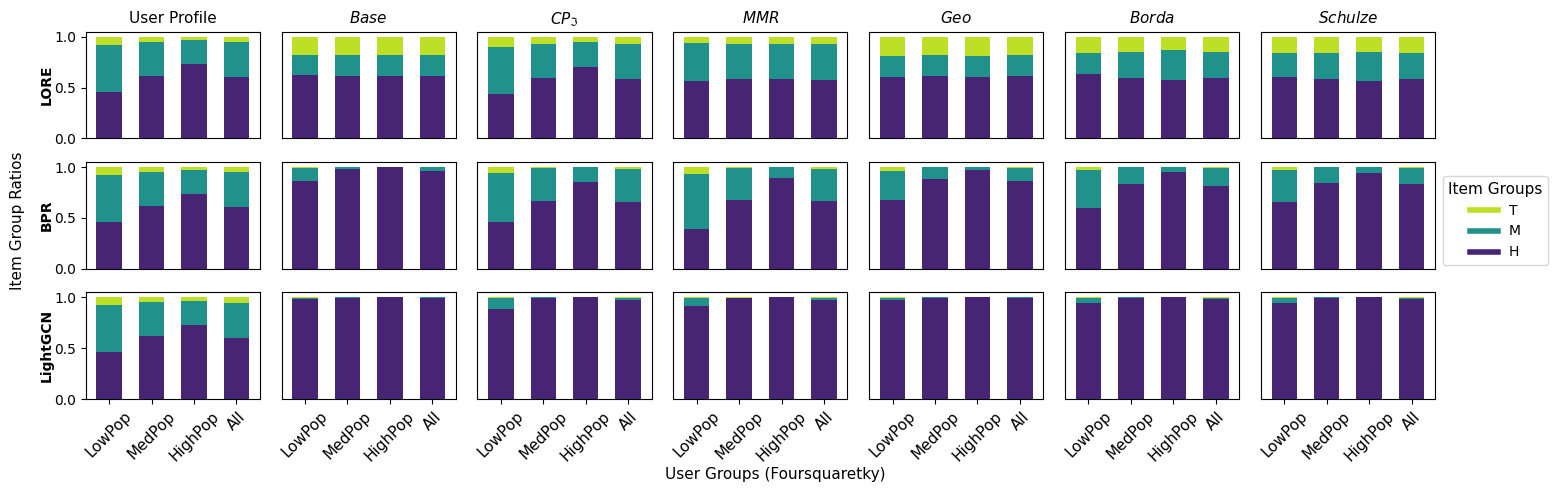

In [87]:
""" Looping through the models and methods to plot the popularity distribution """
fig, axs = plt.subplots(3, 7, figsize=(15, 5.5))  # 3 models x 4 methods
method_names_for_title = ["$Base$", "$CP_\Im$", "$MMR$", "$Geo$", "$Borda$", "$Schulze$"]

# model_dirs_plot = copy.deepcopy(model_dirs)
filtered_models = [
    (model_name, methods)
    for model_name, methods in model_dirs.items()
    if model_name not in ["SimpleX", "USG", "plurality", "borda", "cp"]
]

for i, (model_name, methods) in enumerate(filtered_models):
    # print(model_name)   
    ax = axs[i, 0]
    plot_popularity_distribution(ax, ground_truth_distr, None)  # no title here
    if i == 0:
        ax.set_title("User Profile", fontsize=11)

    for j, (method_name, json_file) in enumerate(methods.items()):
        # print(method_name, json_file)
        df = top_k_to_df(json_file)
        distr_df = create_pop_distributions(df)

        ax = axs[i, j + 1]
        plot_popularity_distribution(ax, distr_df, None)  # no title here
        if i == 0:
            ax.set_title(method_names_for_title[j], fontsize=11)


    axs[i, 0].set_ylabel(model_name, fontsize=10, weight="bold", labelpad=0)

    if i == 5:
                for k in range(7):
                    axs[i, k].set_xticks(range(7))
                    axs[i, k].set_xlabel("User Groups")
    else:
        for k in range(7):
            axs[i, k].set_xlabel("")

for ax in axs[-1, :]:
    ax.set_xticks(range(4))
    ax.set_xticklabels(["LowPop", "MedPop", "HighPop", "All"], rotation=45, fontsize=11)

for row in axs[:-1, :]:
    for ax in row:
        ax.set_xticks([])

for row in axs:
    for ax in row[1:]:
        ax.set_yticks([])


fig.text(0.55, 0.03, f"User Groups ({dataset.capitalize()})", ha="center", fontsize=11)
fig.text(0.04, 0.5, "Item Group Ratios", va="center", rotation="vertical", fontsize=11)

handles = [plt.Line2D([0], [0], color=color, lw=4) for color in plt.cm.viridis([0.9, 0.5, 0.1])]
labels = ["T", "M", "H"]


fig.legend(handles, labels, title="Item Groups", loc="center right", bbox_to_anchor=(1.07, 0.5), ncol=1, title_fontsize=11)
#fig.suptitle(f"Popularity Distribution for {dataset.capitalize()} Dataset", fontsize=12, weight="bold", y=0.87, x=0.57)
plt.tight_layout(rect=[0.05, 0.03, 1, 0.91])
plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", f"{dataset}_popularity_distribution_paper.png"), bbox_inches="tight")


In [88]:
poi_df = load_coordinates(dataset)

Loaded 2804 POI coordinates for dataset 'foursquaretky'


In [89]:
# --- pre-compute once, outside all loops ---
item_sim_matrix, item_idx = build_item_similarity(train_data)
total_catalog_size = train_data["item_id:token"].nunique()
item_coords = dict(zip(poi_df["item_id:token"], zip(poi_df["lat:float"], poi_df["lon:float"])))
distr_dict_ground_truth = preprocess_distr(ground_truth_distr)

# --- tracking dicts ---
group_scores = {}
results = {}
ttest_results = {}

for model_name, methods in model_dirs.items():
    if model_name in ["SimpleX", "USG"]:
        continue

    results[model_name] = {}
    ttest_results[model_name] = {}
    group_scores[model_name] = {}

    for method_name, json_file in methods.items():
        df = top_k_to_df(json_file)

        # --- per-user scores (uniform dict) ---
        df_with_pop = df.merge(item_popularity, on="item_id:token", how="left")
        arp_scores, poplift_scores = calculate_arp_poplift(
            df_with_pop, item_popularity, upts, valid_popularity
        )

        per_user = {
            "ndcg":           ndcg(test_data=test_data, df=df, top_k_eval=top_k_eval),
            "arp":            arp_scores,
            "poplift":        poplift_scores,
            "ild":            behavioral_ild_per_user(df, item_sim_matrix, item_idx),
            "geo_ild":        geographic_ild_per_user(df, item_coords),
            # "dist_traveled":  distance_traveled_per_user(df, item_coords),
        }

        # --- jsd per group ---
        distr_dict_recs = preprocess_distr(create_pop_distributions(df))
        jsd_group = {
            group_gt["user_group"]: jensen_shannon(group_gt, group_recs)
            for group_gt, group_recs in zip(distr_dict_ground_truth, distr_dict_recs)
        }

        # --- aggregate into group means ---
        group_eval, per_user_by_group = evaluation_user_group_means(
            per_user, user_groups, df,
            total_catalog_size=total_catalog_size,
        )

        # --- inject jsd into group_eval ---
        for group_name, jsd_value in jsd_group.items():
            group_eval.setdefault(group_name, {})["js"] = jsd_value

        # --- t-tests over all metrics uniformly ---
        # ttest_results[model_name][method_name] = {
        #     metric: calculate_t_test_between_user_groups(per_user_by_group[metric])
        #     for metric in per_user_by_group
        # }

        group_scores[model_name][method_name] = per_user_by_group
        results[model_name][method_name] = group_eval

Interaction matrix shape: (1500, 2804)
Item similarity matrix shape: (2804, 2804)
[GEO-ILD WARNING] user=1003_x | items=(1460_x, 1968_x) | dist=0.4848m | coords=(35.69001021,139.7058928) vs (35.69001457,139.7058928)
[GEO-ILD WARNING] user=1004_x | items=(1065_x, 375_x) | dist=0.7261m | coords=(35.68892098,139.6995628) vs (35.68892751,139.6995628)
[GEO-ILD WARNING] user=1026_x | items=(500_x, 2435_x) | dist=0.6805m | coords=(35.67701252,139.737044) vs (35.67701687,139.7370493)
[GEO-ILD WARNING] user=1043_x | items=(1460_x, 1968_x) | dist=0.4848m | coords=(35.69001021,139.7058928) vs (35.69001457,139.7058928)
[GEO-ILD WARNING] user=1079_x | items=(1460_x, 1968_x) | dist=0.4848m | coords=(35.69001021,139.7058928) vs (35.69001457,139.7058928)
[GEO-ILD WARNING] user=1089_x | items=(1945_x, 1966_x) | dist=0.7272m | coords=(35.6742127,139.7450584) vs (35.67420616,139.7450584)
[GEO-ILD WARNING] user=1164_x | items=(365_x, 287_x) | dist=0.4788m | coords=(35.65906803,139.700574) vs (35.65906803,

Close entries
items=(1460_x, 1968_x)
items=(1065_x, 375_x)
items=(500_x, 2435_x)
items=(365_x, 287_x) 
items=(365_x, 2348_x) 
items=(287_x, 2348_x)

In [90]:
# old

# """ Looping through the models and methods to store and process the results """
# group_scores_ndcg = {}
# group_scores_arp = {}
# group_scores_poplift = {}
# group_scores_gini = {}
# results = {}
# ttest_results = {}


# # Build once before the model loop, using your training/full interaction data
# item_sim_matrix, item_idx = build_item_similarity(train_data)  # or full interaction df
# total_catalog_size = train_data["item_id:token"].nunique()
# distr_dict_ground_truth = preprocess_distr(ground_truth_distr)

# for i, (model_name, methods) in enumerate(model_dirs.items()):
#     if model_name not in ["SimpleX", "USG"]:
#         results[model_name] = {}
#         ttest_results[model_name] = {}

#         group_scores_ndcg[model_name] = {}
#         group_scores_arp[model_name] = {}
#         group_scores_poplift[model_name] = {}

#         for j, (method_name, json_file) in enumerate(methods.items()):

#             ttest_results[model_name][method_name] = {}
  
#             df = top_k_to_df(json_file)


#             ndcg_scores = ndcg(df=df, test_data=test_data, top_k_eval=top_k_eval)
#             df_with_item_pop = df.merge(item_popularity, on="item_id:token", how="left")
#             arp_scores, poplift_scores = calculate_arp_poplift(df_with_item_pop, item_popularity, upts, valid_popularity)
#             distr_df = create_pop_distributions(df)
#             distr_dict_recs = preprocess_distr(distr_df)

            


#             jsd_group = {}
#             for group_gt, group_recs in zip(distr_dict_ground_truth, distr_dict_recs):
#                 jsd_group[group_gt["user_group"]] = jensen_shannon(group_gt, group_recs)

#             group_eval, group_ndcg_scores, group_arp_scores, group_poplift_scores = evaluation_user_group_means(
#             ndcg_scores, arp_scores, poplift_scores, user_groups, df,
#             total_catalog_size=total_catalog_size
#             )

#             group_scores_ndcg[model_name][method_name] = group_ndcg_scores
#             group_scores_arp[model_name][method_name] = group_arp_scores
#             group_scores_poplift[model_name][method_name] = group_poplift_scores

#             # ttests between low and high / low and medium to check whether LowPop users are disadvantaged
#             # ttest_results[model_name][method_name]["ndcg"] = calculate_t_test_between_user_groups(group_ndcg_scores)
#             # ttest_results[model_name][method_name]["arp"] = calculate_t_test_between_user_groups(group_arp_scores)
#             # ttest_results[model_name][method_name]["poplift"] = calculate_t_test_between_user_groups(group_poplift_scores)
        
#             for group_name, jsd_value in jsd_group.items():
#                 if group_name in group_eval:
#                     group_eval[group_name]["js"] = jsd_value
#                 else:
#                     # In case the group exists in jsd_group but not in group_eval
#                     group_eval[group_name] = {"js": jsd_value}

#             results[model_name][method_name] = group_eval

In [91]:
# def format_raw_results(general_results):
#     rows = []
#     for model, methods in general_results.items():
#         for method, groups in methods.items():
#             for group, metrics in groups.items():
#                 row = {"model": model, "method": method, "group": group}
#                 row.update({k: round(v, 4) for k, v in metrics.items()})
#                 rows.append(row)
    
#     return pd.DataFrame(rows)

# df_results_raw = format_raw_results(results)
# df_results_single_agent = df_results_raw.loc[df_results_raw["method"].isin(["baseline", "cp_min_js", "geo", "mmr"])]
# df_results_aggregate = df_results_raw.loc[df_results_raw["method"].isin(["borda", "schulze"])]
# df_results_raw.to_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "evaluation_results_raw.csv"), index=False)
# df_results_single_agent.to_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "evaluation_results_single_agents.csv"), index=False)
# df_results_aggregate.to_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "evaluation_results_aggregate.csv"), index=False)

In [92]:
# df_results_single_agent.loc[df_results_single_agent["method"] == "baseline"]

In [93]:
def t_tests_rq2(group_scores):
    variants = ["cp_min_js", "mmr", "geo", "borda", "schulze"]
    metrics = ["ndcg", "arp", "poplift", "ild", "geo_ild", "js"]
    ttest_results = {}

    def clean(d):
        return [float(v) for v in d.values() if isinstance(v, (float, int))]

    for model_name, methods in group_scores.items():
        ttest_results[model_name] = {}

        for metric in metrics:
            ttest_results[model_name][metric] = {}

            for group in ["HighPop", "MedPop", "LowPop", "All"]:
                ttest_results[model_name][metric][group] = {}

                baseline_vals = clean(
                    methods.get("baseline", {}).get(metric, {}).get(group, {})
                )

                for variant in variants:
                    variant_vals = clean(
                        methods.get(variant, {}).get(metric, {}).get(group, {})
                    )

                    if baseline_vals and variant_vals:
                        result = pg.ttest(baseline_vals, variant_vals, correction=True)
                        ttest_results[model_name][metric][group][variant] = {
                            "p_val": float(result["p-val"].values[0]),
                            "delta": float(np.mean(variant_vals) - np.mean(baseline_vals)),
                        }
                    else:
                        ttest_results[model_name][metric][group][variant] = {
                            "p_val": None,
                            "delta": None,
                        }

    return ttest_results

In [94]:
ttest_rq2 = t_tests_rq2(group_scores)

/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/bayesian.py:154: RuntimeWarning: overflow encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)
/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/bayesian.py:154: RuntimeWarning: overflow encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)
/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/bayesian.py:154: RuntimeWarning: overflow encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)


In [95]:
ttest_rq2

{'LORE': {'ndcg': {'HighPop': {'cp_min_js': {'p_val': 0.00047347046283723537,
     'delta': 0.012642508327687365},
    'mmr': {'p_val': 0.22952298024799261, 'delta': -0.0025536813365015},
    'geo': {'p_val': 0.6163852392863118, 'delta': 0.001263900909874255},
    'borda': {'p_val': 0.20316366787544418, 'delta': 0.003352883395933221},
    'schulze': {'p_val': 0.8620455313841949, 'delta': 0.0004147336300176687}},
   'MedPop': {'cp_min_js': {'p_val': 2.3498722020314053e-06,
     'delta': 0.013427113511437504},
    'mmr': {'p_val': 7.718494234518412e-05, 'delta': -0.008199968756535302},
    'geo': {'p_val': 0.7534959613290044, 'delta': -0.0007569289444280675},
    'borda': {'p_val': 0.41441174342134357, 'delta': -0.0018344495134586958},
    'schulze': {'p_val': 0.6784524954546276, 'delta': 0.0009932116703278253}},
   'LowPop': {'cp_min_js': {'p_val': 0.25376213289487787,
     'delta': 0.007099585359073627},
    'mmr': {'p_val': 0.047639021931868676, 'delta': -0.010158254775781863},
    'g

In [96]:
group_scores["LORE"]["baseline"]

{'ndcg': {'HighPop': {'10_x': 0.0,
   '1088_x': 0.0,
   '49_x': 0.0,
   '164_x': 0.0,
   '47_x': 0.0,
   '646_x': 0.0,
   '1128_x': 0.0,
   '453_x': 0.0,
   '1072_x': 0.0,
   '336_x': 0.0,
   '1184_x': 0.0,
   '1317_x': 0.0,
   '699_x': 0.0,
   '502_x': 0.0,
   '528_x': 0.0,
   '140_x': 0.0,
   '578_x': 0.0,
   '964_x': 0.0,
   '1123_x': 0.0,
   '1102_x': 0.0,
   '817_x': 0.0,
   '1057_x': 0.0,
   '801_x': 0.0,
   '929_x': 0.0,
   '1412_x': 0.0,
   '509_x': 0.0,
   '307_x': 0.0,
   '684_x': 0.0,
   '1373_x': 0.0,
   '1009_x': 0.0,
   '1063_x': 0.0,
   '244_x': 0.123151194370365,
   '315_x': 0.0,
   '416_x': 0.0,
   '974_x': 0.0,
   '789_x': 0.0,
   '156_x': 0.0,
   '842_x': 0.0,
   '1104_x': 0.0,
   '1497_x': 0.0,
   '1024_x': 0.0,
   '945_x': 0.13032376591037062,
   '1259_x': 0.0,
   '537_x': 0.09546043308946733,
   '291_x': 0.0,
   '1480_x': 0.0,
   '941_x': 0.0,
   '182_x': 0.0,
   '1078_x': 0.0,
   '314_x': 0.0,
   '845_x': 0.0,
   '71_x': 0.0,
   '1089_x': 0.0,
   '1207_x': 0.0,
 

In [97]:
def format_results_rq2_with_deltas(general_results, ttest_rq2):
    """Format the results to put them into a table including the Delta in Percent and +/-"""
    updated_results = copy.deepcopy(general_results)

    for model in general_results:
        for group in general_results[model]["baseline"]:
            for metric in ["ndcg", "arp", "poplift", "gini", "js"]:
                base_val = general_results[model]["baseline"][group][metric]
                updated_results[model]["baseline"][group][metric] = f"{base_val:.4f}"

            for method in ["cp_min_js", "mmr", "geo", "borda", "schulze"]:
                if method not in general_results[model]:
                    continue
                if group not in general_results[model][method]:
                    continue

                for metric in ["ndcg", "arp", "poplift"]:
                    cur_val = general_results[model][method][group][metric]
                    try:
                        delta = ttest_rq2[model][metric][group][method]["delta"]
                        p_val = ttest_rq2[model][metric][group][method]["p_val"]
                    except KeyError:
                        continue

                    base_val = float(general_results[model]["baseline"][group][metric])
                    delta_percent = ((cur_val - base_val) / abs(base_val)) * 100 if base_val != 0 else 0
                    delta_str = f"{delta_percent:+.2f}%"
                    if p_val < 0.05 / 32:
                        delta_str += "**"

                    updated_results[model][method][group][metric] = f"{cur_val:.4f} ({delta_str})"

    return updated_results


df_results_rq2 = format_results_rq2_with_deltas(results, ttest_rq2)

In [98]:
df_results_rq2

{'LORE': {'baseline': {'HighPop': {'ndcg': '0.0057',
    'arp': '0.0062',
    'poplift': '-0.8740',
    'ild': 0.9408377020929173,
    'geo_ild': 0.37279514324872076,
    'gini': '0.7774',
    'js': '0.2391'},
   'LowPop': {'ndcg': '0.0209',
    'arp': '0.0069',
    'poplift': '-0.4715',
    'ild': 0.9406670900211176,
    'geo_ild': 0.49004187336386207,
    'gini': '0.6783',
    'js': '0.0723'},
   'MedPop': {'ndcg': '0.0156',
    'arp': '0.0064',
    'poplift': '-0.7920',
    'ild': 0.9394814251895203,
    'geo_ild': 0.4146205592745313,
    'gini': '0.6899',
    'js': '0.1600'},
   'All': {'ndcg': '0.0147',
    'arp': '0.0064',
    'poplift': '-0.7443',
    'ild': 0.9399898135365192,
    'geo_ild': 0.4213397388872354,
    'gini': '0.6559',
    'js': '0.1512'}},
  'cp_min_js': {'HighPop': {'ndcg': '0.0183 (+222.77%**)',
    'arp': '0.0149 (+139.93%**)',
    'poplift': '-0.6986 (+20.06%**)',
    'ild': 0.9225069494410263,
    'geo_ild': 0.6574475515583498,
    'gini': 0.8504210651450309

In [99]:
def plot_metric(results, metric, dataset):
    """Plot a line chart with the evolution of each metric"""
    n_models = len(results)
    n_cols = 2
    n_rows = math.ceil(n_models / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(17, 3 * n_rows))
    axs = axs.flatten()  # Flatten to simplify indexing

    for i, (model_name, methods) in enumerate(results.items()):
        plot_line_chart(results, model_name, axs[i], metric)
        axs[i].set_ylabel(model_name, fontsize=12, weight="bold")

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])  # Remove unused subplots

    fig.suptitle(f"{metric.upper()} Comparison for {dataset}", fontsize=18, weight="bold", x=0.5)

    ndcg_handles = [plt.Line2D([0], [0], color=color, lw=2, marker="o") for color in plt.cm.viridis([0.2, 0.6, 0.8, 0.3])]
    ndcg_labels = ["HighPop", "MedPop", "LowPop", "All"]
    fig.legend(ndcg_handles, ndcg_labels, title="User Groups", loc="upper center", bbox_to_anchor=(0.5, 0.92), ncol=4)

    plt.tight_layout(rect=[0, 0.02, 1, 0.88])  # Reduced bottom space
    os.makedirs(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots"), exist_ok=True)

    # Save the plot
    plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", f"{dataset}_{metric}_comparison.png"))



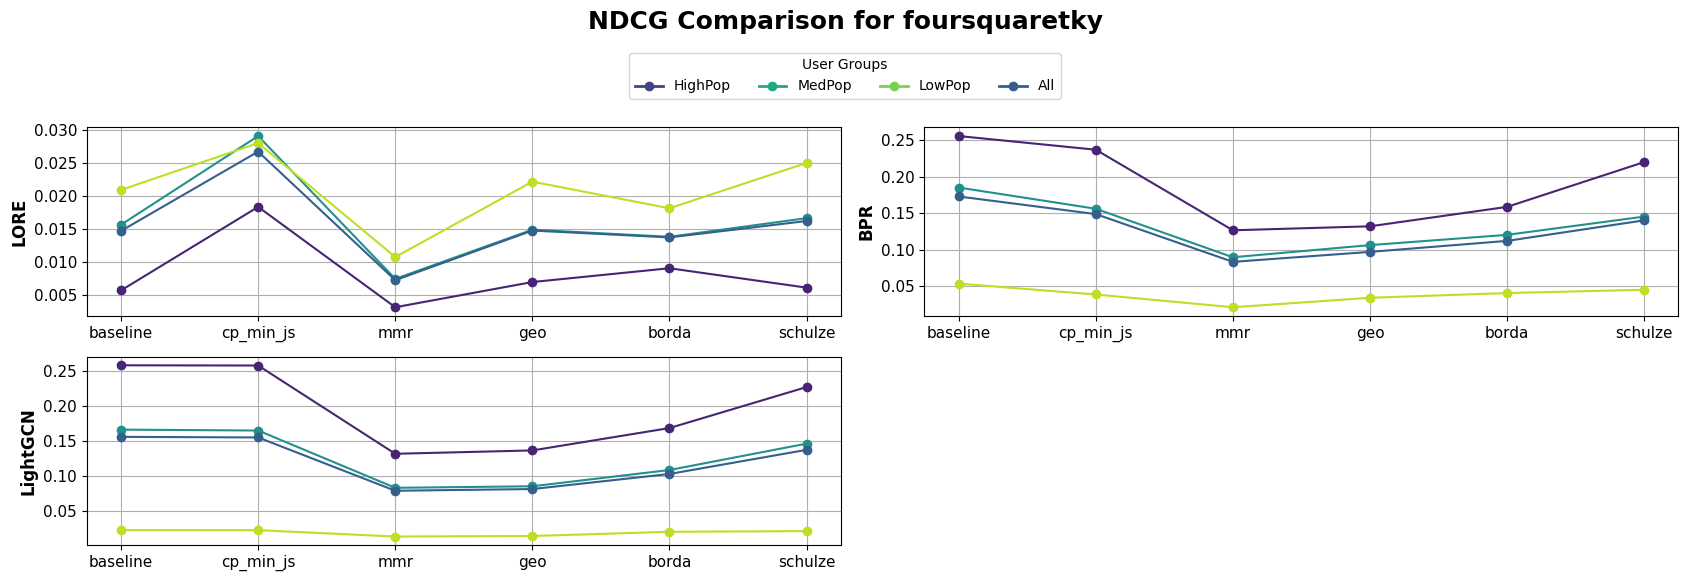

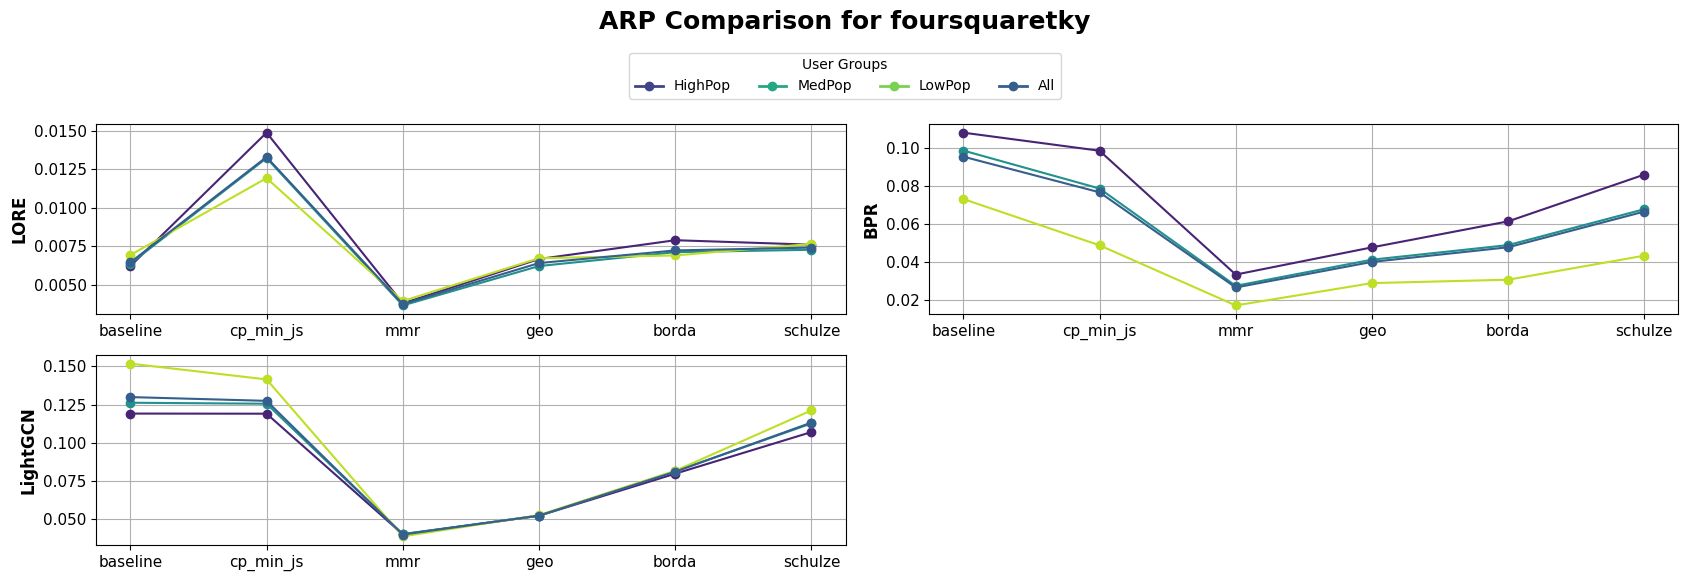

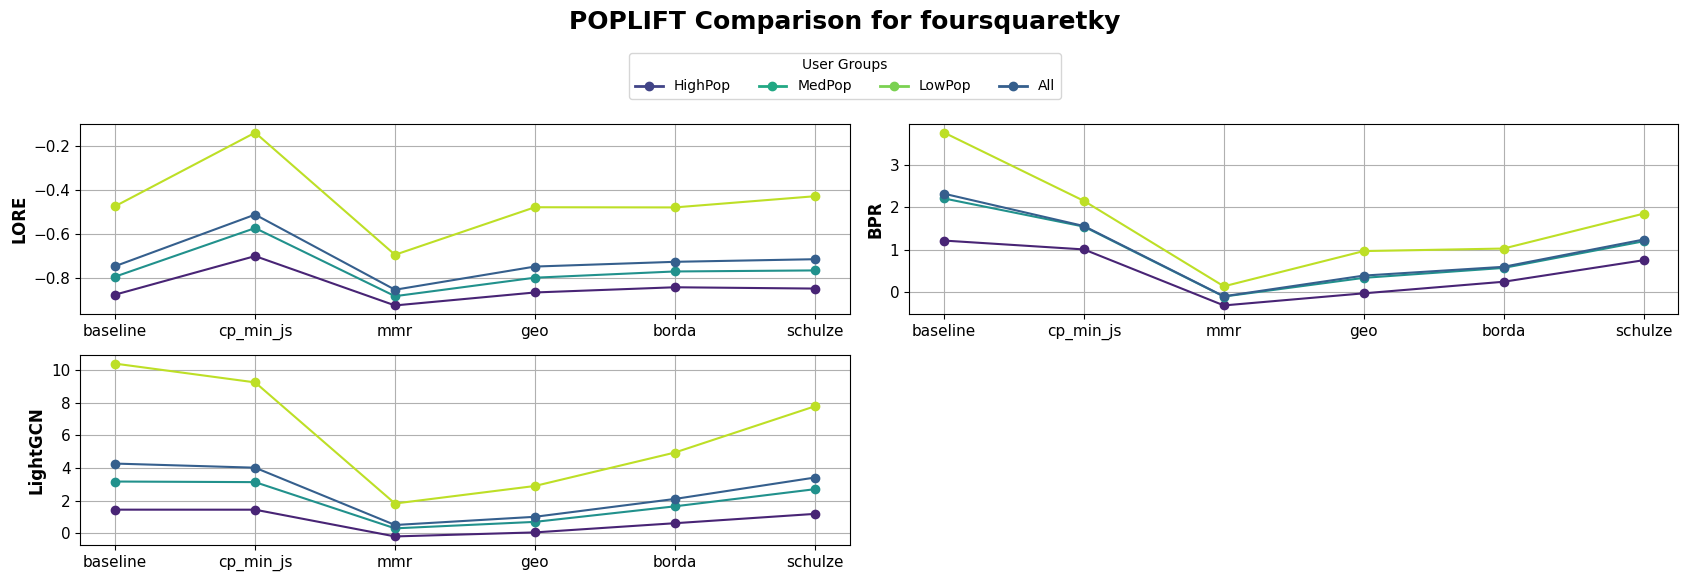

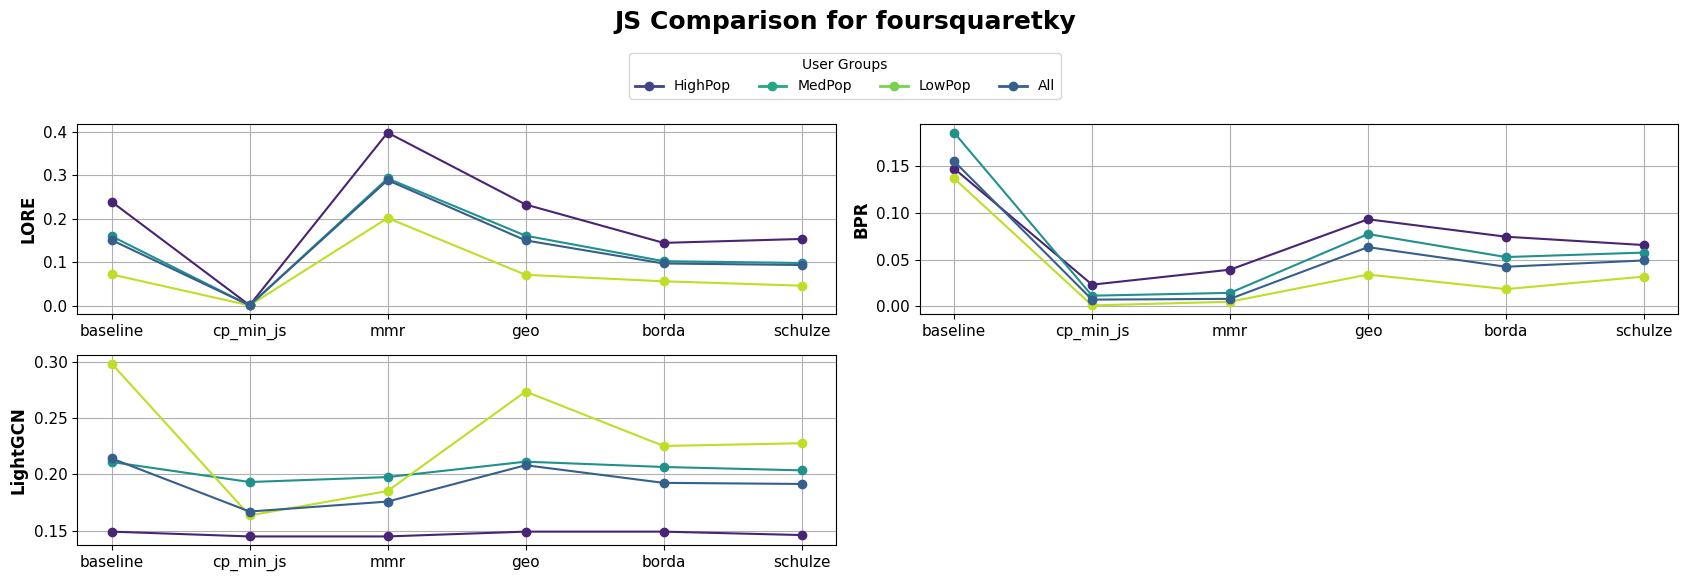

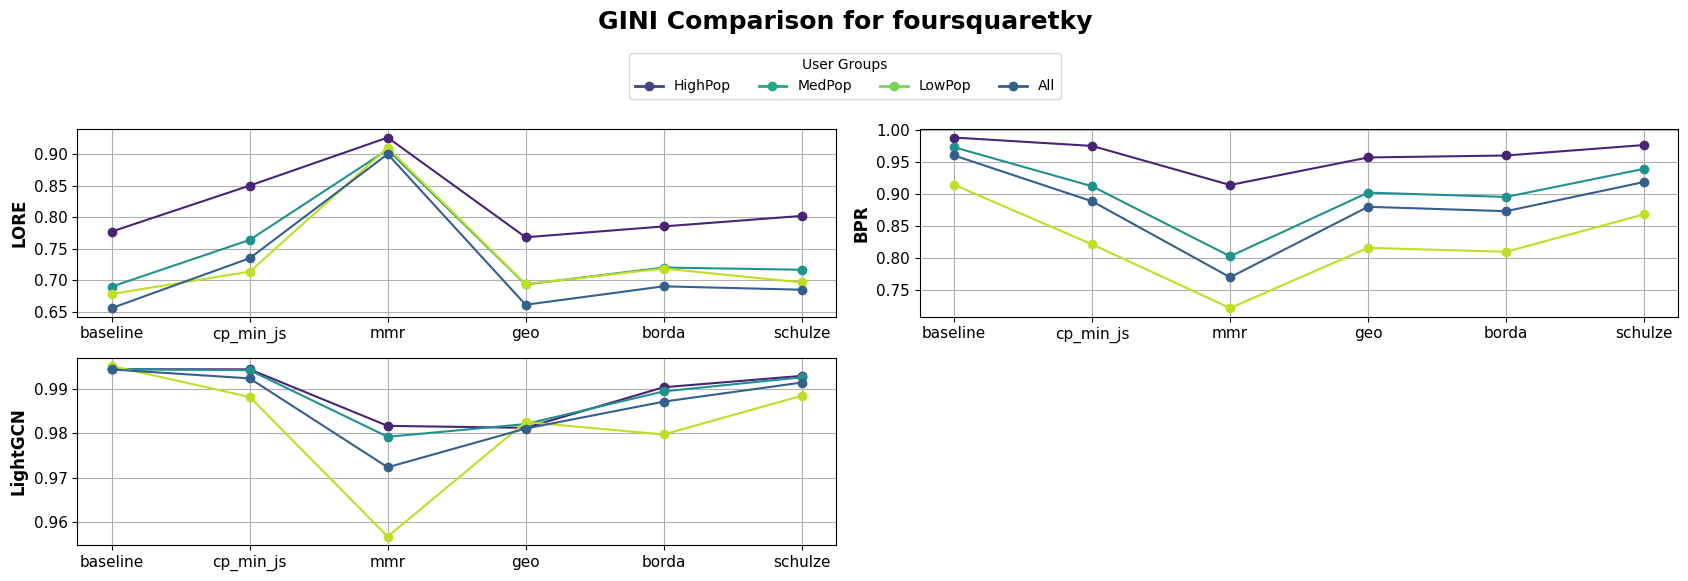

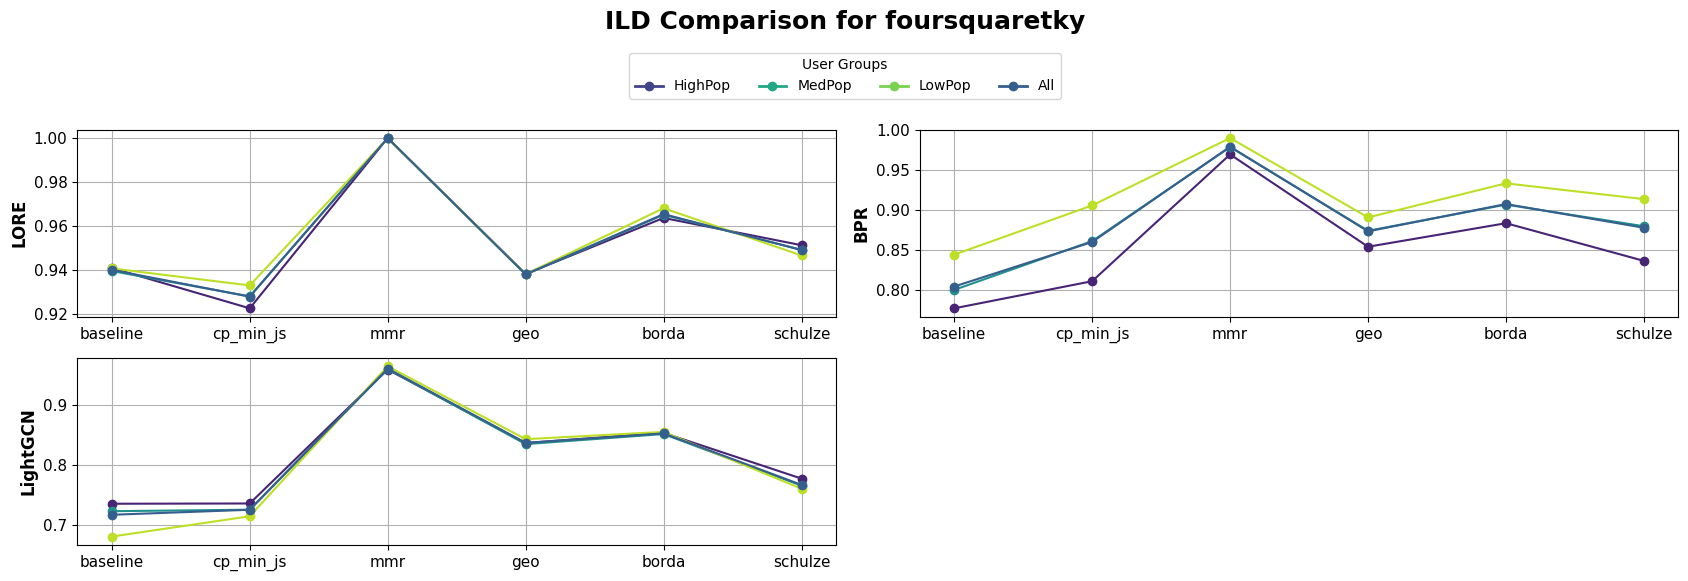

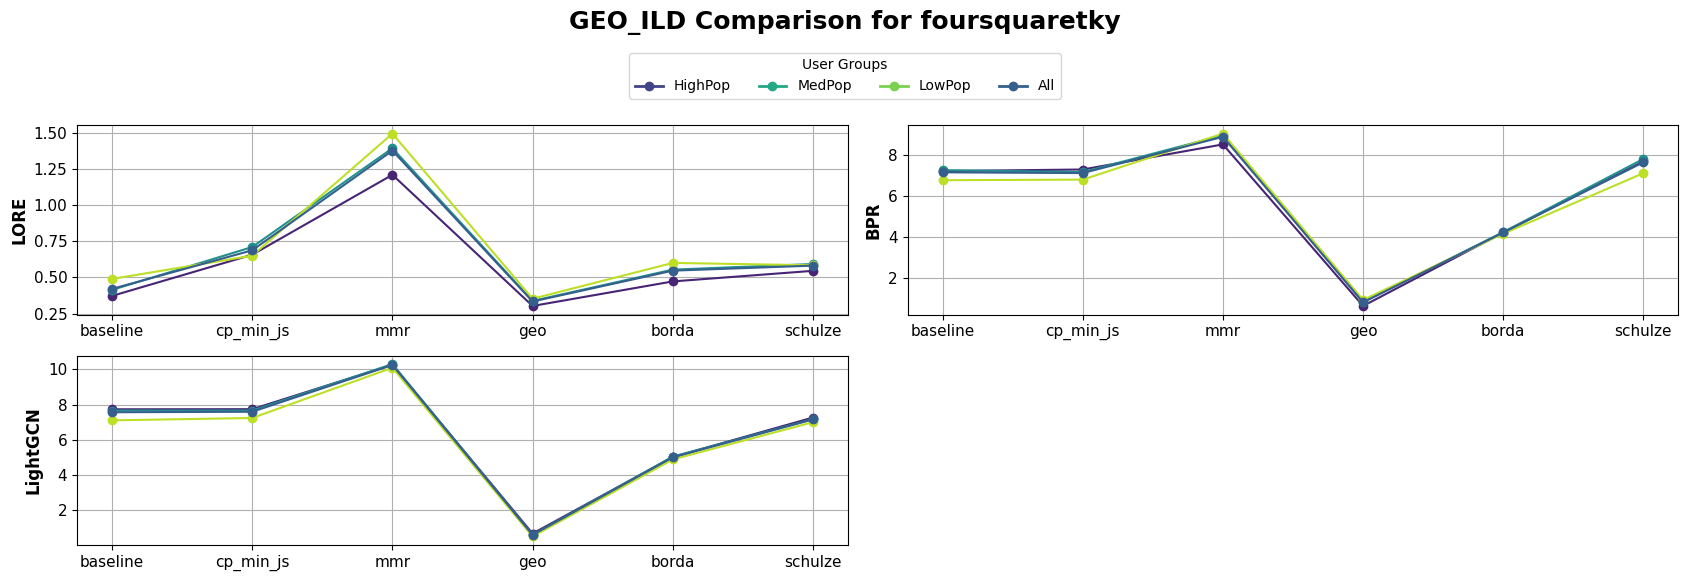

In [100]:

#plot_popularity_distributions(model_dirs, ground_truth_distr, dataset)
plot_metric(results, "ndcg", dataset)
plot_metric(results, "arp", dataset)
plot_metric(results, "poplift", dataset)
plot_metric(results, "js", dataset)
plot_metric(results, "gini", dataset)
plot_metric(results, "ild", dataset)
plot_metric(results, "geo_ild", dataset)

In [101]:
results

{'LORE': {'baseline': {'HighPop': {'ndcg': 0.005675016346312142,
    'arp': 0.006198882548739896,
    'poplift': -0.8739596558712496,
    'ild': 0.9408377020929173,
    'geo_ild': 0.37279514324872076,
    'gini': 0.7774141702330004,
    'js': 0.2391346495886949},
   'LowPop': {'ndcg': 0.020884440253380737,
    'arp': 0.006919044222539228,
    'poplift': -0.4715008892302914,
    'ild': 0.9406670900211176,
    'geo_ild': 0.49004187336386207,
    'gini': 0.6782715168806467,
    'js': 0.07229245254990173},
   'MedPop': {'ndcg': 0.015619624893373235,
    'arp': 0.0063634490410524654,
    'poplift': -0.7920299789075163,
    'ild': 0.9394814251895203,
    'geo_ild': 0.4146205592745313,
    'gini': 0.6899337454430176,
    'js': 0.16004570448203928},
   'All': {'ndcg': 0.014683666255962517,
    'arp': 0.006441654778887303,
    'poplift': -0.744310096364818,
    'ild': 0.9399898135365192,
    'geo_ild': 0.4213397388872354,
    'gini': 0.6558592486923441,
    'js': 0.1511670142324692}},
  'cp_min

In [102]:
results

{'LORE': {'baseline': {'HighPop': {'ndcg': 0.005675016346312142,
    'arp': 0.006198882548739896,
    'poplift': -0.8739596558712496,
    'ild': 0.9408377020929173,
    'geo_ild': 0.37279514324872076,
    'gini': 0.7774141702330004,
    'js': 0.2391346495886949},
   'LowPop': {'ndcg': 0.020884440253380737,
    'arp': 0.006919044222539228,
    'poplift': -0.4715008892302914,
    'ild': 0.9406670900211176,
    'geo_ild': 0.49004187336386207,
    'gini': 0.6782715168806467,
    'js': 0.07229245254990173},
   'MedPop': {'ndcg': 0.015619624893373235,
    'arp': 0.0063634490410524654,
    'poplift': -0.7920299789075163,
    'ild': 0.9394814251895203,
    'geo_ild': 0.4146205592745313,
    'gini': 0.6899337454430176,
    'js': 0.16004570448203928},
   'All': {'ndcg': 0.014683666255962517,
    'arp': 0.006441654778887303,
    'poplift': -0.744310096364818,
    'ild': 0.9399898135365192,
    'geo_ild': 0.4213397388872354,
    'gini': 0.6558592486923441,
    'js': 0.1511670142324692}},
  'cp_min

In [103]:
rows = []
for model, methods in results.items():
    for method, metrics in methods.items():
        if "All" in metrics:
            rows.append({"model": model, "method": method, **metrics["All"]})

df_all = pd.DataFrame(rows).set_index(["model", "method"])
print(df_all.to_string(float_format="{:.4f}".format))

                     ndcg    arp  poplift    ild  geo_ild   gini     js
model    method                                                        
LORE     baseline  0.0147 0.0064  -0.7443 0.9400   0.4213 0.6559 0.1512
         cp_min_js 0.0267 0.0133  -0.5099 0.9278   0.6880 0.7350 0.0012
         mmr       0.0072 0.0037  -0.8518 1.0000   1.3767 0.9004 0.2887
         geo       0.0147 0.0064  -0.7463 0.9380   0.3341 0.6611 0.1505
         borda     0.0137 0.0072  -0.7247 0.9654   0.5473 0.6904 0.0975
         schulze   0.0162 0.0074  -0.7129 0.9490   0.5820 0.6850 0.0940
BPR      baseline  0.1730 0.0955   2.3225 0.8043   7.1707 0.9602 0.1552
         cp_min_js 0.1489 0.0767   1.5564 0.8599   7.1344 0.8888 0.0071
         mmr       0.0836 0.0265  -0.1084 0.9790   8.9064 0.7704 0.0079
         geo       0.0973 0.0400   0.3821 0.8733   0.8193 0.8802 0.0633
         borda     0.1123 0.0477   0.5903 0.9074   4.2326 0.8734 0.0423
         schulze   0.1404 0.0665   1.2363 0.8778   7.6635 0.9188

In [104]:
def highlight_best(df, higher_is_better, lower_is_better):
    latex_df = df.copy()
    for col in higher_is_better:
        if col in latex_df.columns:
            best_idx = latex_df[col].idxmax()
            latex_df[col] = latex_df[col].apply(lambda x: f"{x:.4f}")
            latex_df.at[best_idx, col] = f"\\textbf{{{latex_df.at[best_idx, col]}}}"
    for col in lower_is_better:
        if col in latex_df.columns:
            best_idx = latex_df[col].idxmin()
            latex_df[col] = latex_df[col].apply(lambda x: f"{x:.4f}")
            latex_df.at[best_idx, col] = f"\\textbf{{{latex_df.at[best_idx, col]}}}"
    return latex_df

higher = ["ndcg", "ild"]
lower  = ["arp", "poplift", "gini", "js", "geo_ild", "dist_traveled"]

formatted_df = highlight_best(df_all, higher, lower)

print(formatted_df.to_latex(
    multirow=False,
    caption="Evaluation results for all methods across models (All user group)",
    label="tab:results_all",
    escape=False,   # needed so \textbf renders correctly
))

\begin{table}
\caption{Evaluation results for all methods across models (All user group)}
\label{tab:results_all}
\begin{tabular}{lllllllll}
\toprule
 &  & ndcg & arp & poplift & ild & geo_ild & gini & js \\
model & method &  &  &  &  &  &  &  \\
\midrule
LORE & baseline & 0.0147 & 0.0064 & -0.7443 & 0.9400 & 0.4213 & \textbf{0.6559} & 0.1512 \\
 & cp_min_js & 0.0267 & 0.0133 & -0.5099 & 0.9278 & 0.6880 & 0.7350 & \textbf{0.0012} \\
 & mmr & 0.0072 & \textbf{0.0037} & \textbf{-0.8518} & \textbf{1.0000} & 1.3767 & 0.9004 & 0.2887 \\
 & geo & 0.0147 & 0.0064 & -0.7463 & 0.9380 & \textbf{0.3341} & 0.6611 & 0.1505 \\
 & borda & 0.0137 & 0.0072 & -0.7247 & 0.9654 & 0.5473 & 0.6904 & 0.0975 \\
 & schulze & 0.0162 & 0.0074 & -0.7129 & 0.9490 & 0.5820 & 0.6850 & 0.0940 \\
BPR & baseline & \textbf{0.1730} & 0.0955 & 2.3225 & 0.8043 & 7.1707 & 0.9602 & 0.1552 \\
 & cp_min_js & 0.1489 & 0.0767 & 1.5564 & 0.8599 & 7.1344 & 0.8888 & 0.0071 \\
 & mmr & 0.0836 & 0.0265 & -0.1084 & 0.9790 & 8.9064 & 0

In [105]:
print(top_k_eval)

10


In [106]:
results["BPR"]

{'baseline': {'HighPop': {'ndcg': 0.25563283946514326,
   'arp': 0.10809712315739418,
   'poplift': 1.2119689167284662,
   'ild': 0.7770419699890433,
   'geo_ild': 7.23195104933402,
   'gini': 0.9880670470756062,
   'js': 0.1474542080231595},
  'LowPop': {'ndcg': 0.05381412561554553,
   'arp': 0.07314265335235379,
   'poplift': 3.7703734048624993,
   'ild': 0.8441140204593887,
   'geo_ild': 6.786007619342101,
   'gini': 0.9144826438421303,
   'js': 0.136914332939642},
  'MedPop': {'ndcg': 0.1852419664120057,
   'arp': 0.09867855444602948,
   'poplift': 2.2100501595851583,
   'ild': 0.800064468721002,
   'geo_ild': 7.278466595814317,
   'gini': 0.9729228086860041,
   'js': 0.18589992225219704},
  'All': {'ndcg': 0.17303457286334117,
   'arp': 0.0954550879695673,
   'poplift': 2.3224985600692882,
   'ild': 0.8042698793222876,
   'geo_ild': 7.1706716912238155,
   'gini': 0.9601665715644317,
   'js': 0.15524777454820254}},
 'cp_min_js': {'HighPop': {'ndcg': 0.23692962443975873,
   'arp': 0